In [2]:
import pandas as pd

df = pd.read_csv("data/dreaddit-train.csv")
print(df.head())
print(df.info())

          subreddit post_id sentence_range  \
0              ptsd  8601tu       (15, 20)   
1        assistance  8lbrx9         (0, 5)   
2              ptsd  9ch1zh       (15, 20)   
3     relationships  7rorpp        [5, 10]   
4  survivorsofabuse  9p2gbc         [0, 5]   

                                                text     id  label  \
0  He said he had not felt that way before, sugge...  33181      1   
1  Hey there r/assistance, Not sure if this is th...   2606      0   
2  My mom then hit me with the newspaper and it s...  38816      1   
3  until i met my new boyfriend, he is amazing, h...    239      1   
4  October is Domestic Violence Awareness Month a...   1421      1   

   confidence  social_timestamp  social_karma  syntax_ari  ...  \
0         0.8        1521614353             5    1.806818  ...   
1         1.0        1527009817             4    9.429737  ...   
2         0.8        1535935605             2    7.769821  ...   
3         0.6        1516429555       

In [3]:
print(df.isnull().sum())

df = df.dropna()

subreddit                   0
post_id                     0
sentence_range              0
text                        0
id                          0
                           ..
lex_dal_avg_pleasantness    0
social_upvote_ratio         0
social_num_comments         0
syntax_fk_grade             0
sentiment                   0
Length: 116, dtype: int64


In [4]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'http\S+', '', text)  # remove links
    text = re.sub(r'[^a-zA-Z ]', '', text)  # remove special chars
    return text

df['text'] = df['text'].apply(clean_text)

In [5]:
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

C:\Users\ratnp\AppData\Local\Temp\ipykernel_18996\4094495465.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, palette='Set2')


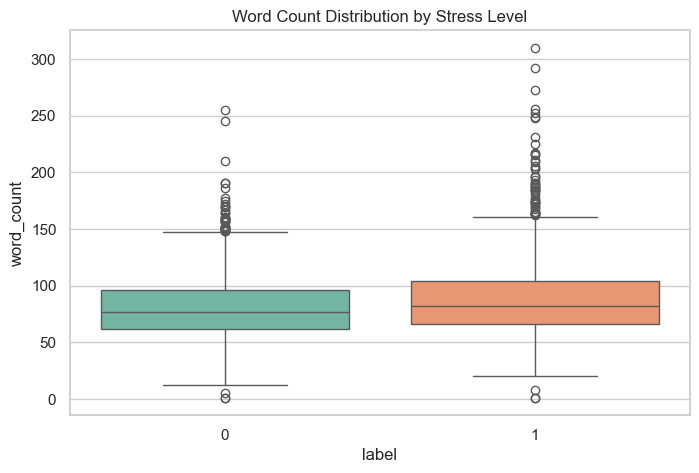

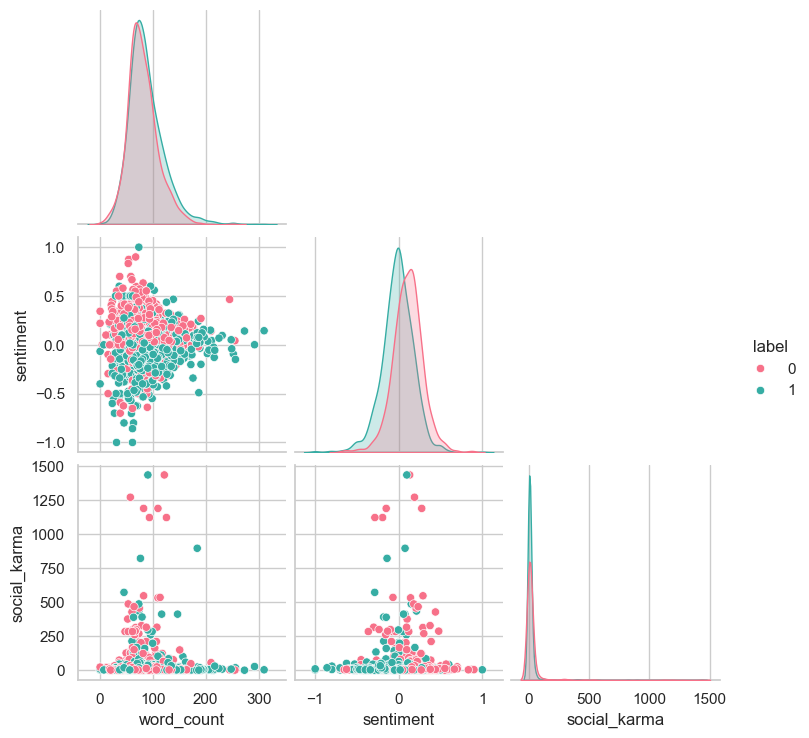

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt



# 2. Boxplot: Shows how word count varies between stressed and non-stressed text
plt.figure(figsize=(8, 5))
sns.boxplot(x='label', y='word_count', data=df, palette='Set2')
plt.title('Word Count Distribution by Stress Level')
plt.show()

# 3. Pairplot: Explores relationships between your key numerical metrics
# Note: Using 'sentiment' and 'social_karma' which are already in your dataset
features = ['word_count', 'sentiment', 'social_karma', 'label']
sns.pairplot(df[features], hue='label', corner=True, palette='husl')
plt.show()

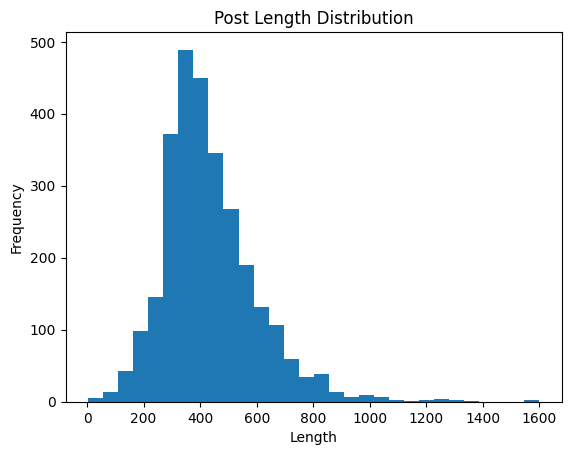

In [6]:
import matplotlib.pyplot as plt

df['length'] = df['text'].apply(len)

plt.hist(df['length'], bins=30)
plt.title("Post Length Distribution")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

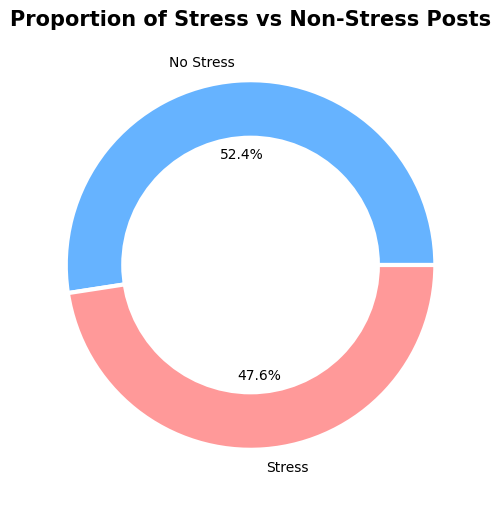

In [7]:

import matplotlib.pyplot as plt
import seaborn as sns

# labels for the pie chart (0 = No Stress, 1 = Stress)
labels = ['No Stress', 'Stress']

# counting how many 0s and 1s are there in the dataset(which gives the distribution of classes)
sizes = df['label'].value_counts()
colors = ['#66b3ff','#ff9999'] # Soft Blue&Red

plt.figure(figsize=(8,6))
plt.pie(sizes, labels=labels, autopct='%1.1f%%',# shows percentage values on the chart
        colors=colors, wedgeprops={'edgecolor': 'white', 'linewidth': 3})

#covert pie chart into this
center_circle = plt.Circle((0,0), 0.70, fc='white')
fig = plt.gcf()
fig.gca().add_artist(center_circle)

plt.title("Proportion of Stress vs Non-Stress Posts", fontsize=15, fontweight='bold')
plt.show()


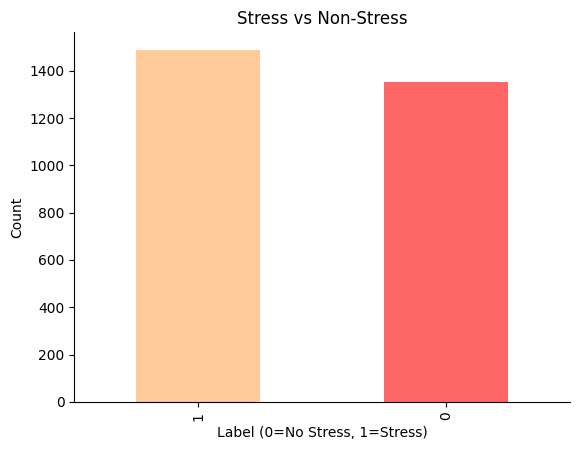

In [8]:
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar',color=['#ffcc99', '#ff6666'])
plt.title("Stress vs Non-Stress")
plt.xlabel("Label (0=No Stress, 1=Stress)")
plt.ylabel("Count")
sns.despine() #removes the top and right borders 
plt.show()


In [9]:
# 1. Calculate Mean and Median for Numerical Data
print("--- Text Length Statistics ---")
print(f"Mean Length: {df['length'].mean():.2f}")
print(f"Median Length: {df['length'].median():.2f}")

print("\n--- Sentiment Statistics ---")
print(f"Mean Sentiment Score: {df['sentiment'].mean():.4f}")

# 2. Calculate Mode for Categorical Data
print("\n--- Frequency Statistics (Mode) ---")
print(f"Most Frequent Subreddit: {df['subreddit'].mode()[0]}")
print(f"Most Common Label: {df['label'].mode()[0]} (1=Stress, 0=No Stress)")

# 3. Descriptive Summary Table
print("\n--- General Summary ---")
print(df[['length', 'sentiment', 'confidence']].describe())


--- Text Length Statistics ---
Mean Length: 432.98
Median Length: 407.00

--- Sentiment Statistics ---
Mean Sentiment Score: 0.0407

--- Frequency Statistics (Mode) ---
Most Frequent Subreddit: ptsd
Most Common Label: 1 (1=Stress, 0=No Stress)

--- General Summary ---
            length    sentiment   confidence
count  2838.000000  2838.000000  2838.000000
mean    432.975335     0.040740     0.808972
std     165.270750     0.195490     0.177038
min       4.000000    -1.000000     0.428571
25%     326.000000    -0.072222     0.600000
50%     407.000000     0.044821     0.800000
75%     512.000000     0.166667     1.000000
max    1599.000000     1.000000     1.000000


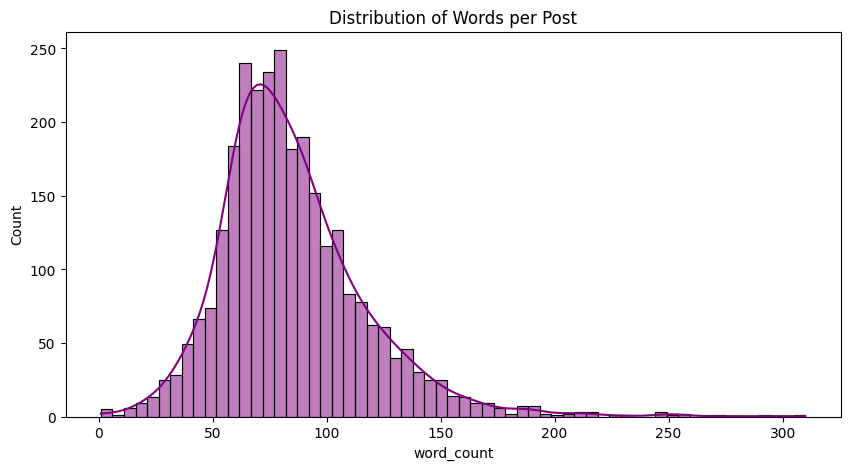

In [10]:
plt.figure(figsize=(10,5))
sns.histplot(df['word_count'], kde=True, color='purple')
plt.title("Distribution of Words per Post")
plt.show()


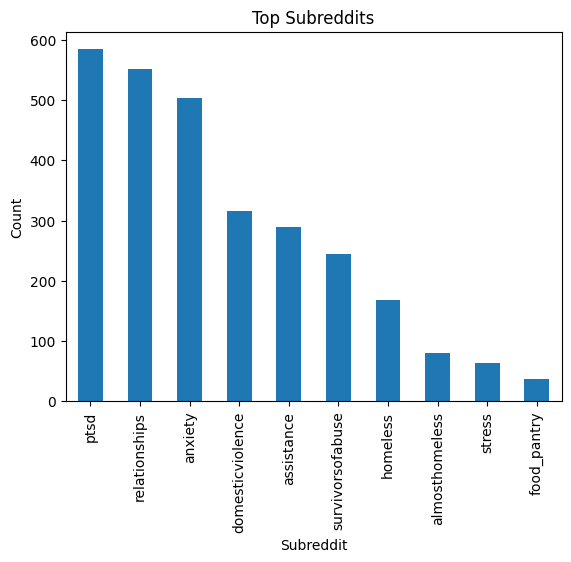

In [11]:
df['subreddit'].value_counts().head(10).plot(kind='bar')
plt.title("Top Subreddits")
plt.xlabel("Subreddit")
plt.ylabel("Count")
plt.show()

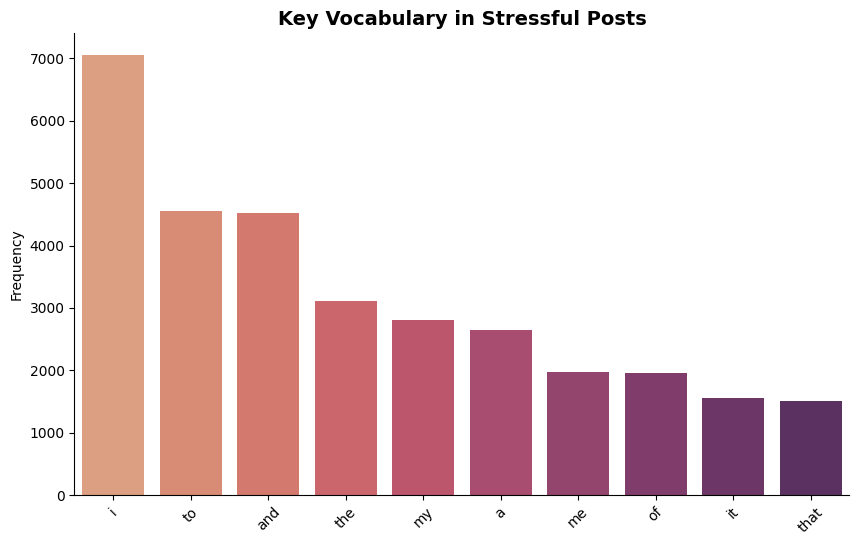

In [12]:
from collections import Counter

stress_text = " ".join(df[df['label']==1]['text'])
words = stress_text.split()

common_words = Counter(words).most_common(10)

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]
plt.figure(figsize=(10, 6))
#flare--soft red/pink gradient
sns.barplot(x=words, y=counts, palette="flare", hue=words, legend=False)

plt.title("Key Vocabulary in Stressful Posts", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Frequency")
sns.despine()
plt.show()

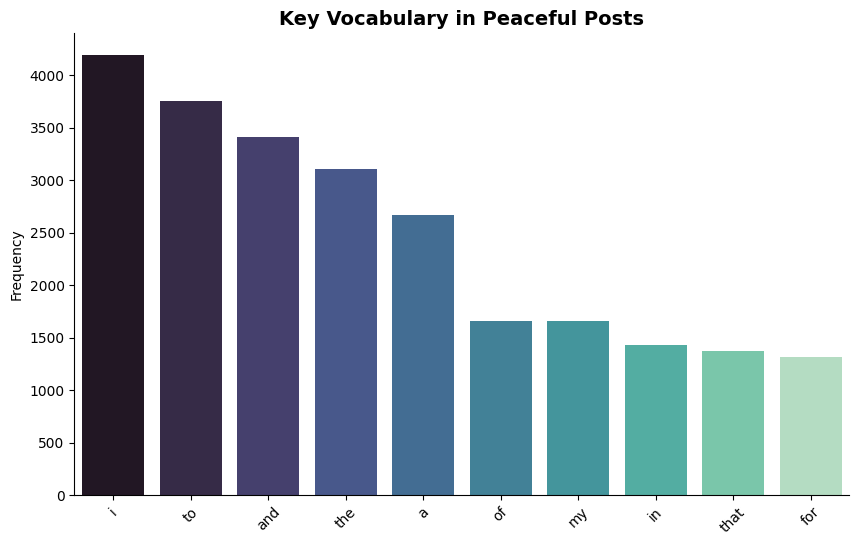

In [13]:
non_stress_text = " ".join(df[df['label']==0]['text'])
words = non_stress_text.split()

common_words = Counter(words).most_common(10)

words = [i[0] for i in common_words]
counts = [i[1] for i in common_words]

plt.figure(figsize=(10, 6))
#mako-teal/blue
sns.barplot(x=words, y=counts, palette="mako", hue=words, legend=False)

plt.title("Key Vocabulary in Peaceful Posts", fontsize=14, fontweight='bold')
plt.xticks(rotation=45)
plt.ylabel("Frequency")
sns.despine() 
plt.show()

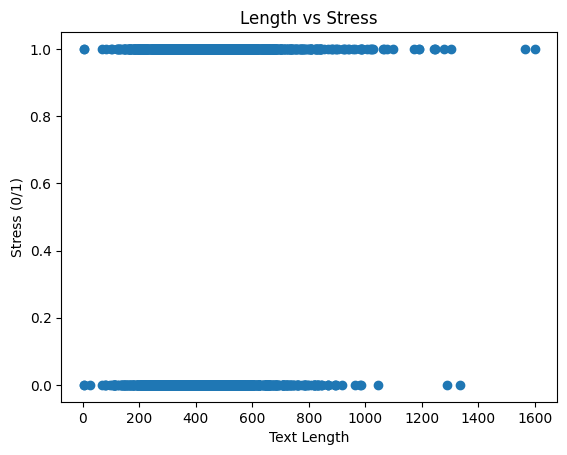

In [14]:
plt.scatter(df['length'], df['label'])
plt.xlabel("Text Length")
plt.ylabel("Stress (0/1)")
plt.title("Length vs Stress")
plt.show()


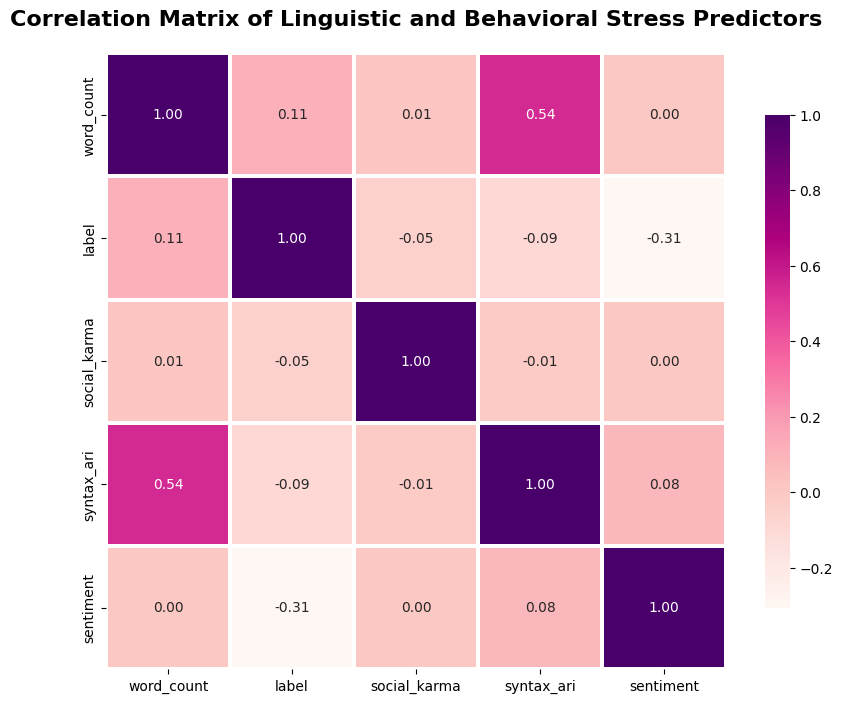

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select numerical columns for correlation
# We include our new 'word_count' and the target 'label'
corr_cols = ['word_count', 'label', 'social_karma', 'syntax_ari', 'sentiment']
# Filter only columns that exist in the df
existing_cols = [c for c in corr_cols if c in df.columns]

plt.figure(figsize=(10, 8))
sns.heatmap(df[existing_cols].corr(), 
            annot=True, 
            cmap='RdPu', 
            fmt='.2f', 
            linewidths=1.5, 
            linecolor='white',
            cbar_kws={'shrink': .8})
plt.title("Correlation Matrix of Linguistic and Behavioral Stress Predictors", 
          fontsize=16, 
          fontweight='bold', 
          pad=20)
plt.show()

In [16]:


import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler  # <--- Add this

# 1. Text Vectorization (Top 500 words)
vectorizer = TfidfVectorizer(max_features=500)
text_features = vectorizer.fit_transform(df['text']).toarray()
scaler = MinMaxScaler()

# 2. Extract Numerical Feature (Behavioral Data)

num_features = scaler.fit_transform(df[['word_count']])

# 3. Feature Fusion (Combining Text + Numbers)
X = np.hstack((text_features, num_features))
y = df['label']

print(f"New Feature Shape: {X.shape}") # It should show (2838, 501)

New Feature Shape: (2838, 501)


In [17]:
from sklearn.model_selection import train_test_split

# splitting data into training and testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [18]:
from sklearn.linear_model import LogisticRegression

## creating the model (logistic regression for classification)
model = LogisticRegression(max_iter=1000)
# training the model on training data
model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [19]:
#generating predictions
y_pred = model.predict(X_test)

# Print the first 5 predictions to see it's working (0 or 1)
print("First 5 predictions:", y_pred[:5])

First 5 predictions: [0 1 1 1 1]


In [20]:
# Get feature names (words)
feature_names = vectorizer.get_feature_names_out()

# Get importance of each word from model
coefficients = model.coef_[0]

# Top words indicating stress
top_stress_words = sorted(zip(feature_names, coefficients), key=lambda x: x[1], reverse=True)[:10]

# Top words indicating no stress
top_nonstress_words = sorted(zip(feature_names, coefficients), key=lambda x: x[1])[:10]

print("Top Stress Words:", top_stress_words)
print("Top Non-Stress Words:", top_nonstress_words)

Top Stress Words: [('me', np.float64(3.299069537043177)), ('im', np.float64(2.4095391384537512)), ('cant', np.float64(2.2744092508790597)), ('even', np.float64(2.175655152045678)), ('feel', np.float64(2.0054804631130363)), ('dont', np.float64(1.9190359806611943)), ('am', np.float64(1.8743334345996625)), ('anxiety', np.float64(1.801629835353246)), ('what', np.float64(1.7262318738694253)), ('fucking', np.float64(1.6664822879984564))]
Top Non-Stress Words: [('you', np.float64(-1.9509311978693153)), ('met', np.float64(-1.8273035823745976)), ('url', np.float64(-1.6794556925042055)), ('that', np.float64(-1.4400177799181588)), ('bit', np.float64(-1.4200658145615648)), ('years', np.float64(-1.4118685543221057)), ('many', np.float64(-1.386143963199973)), ('be', np.float64(-1.37856297253624)), ('experience', np.float64(-1.3056081839337312)), ('guy', np.float64(-1.2738559051558778))]


In [21]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## calculating accuracy (how many correct predictions)
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Accuracy: {accuracy * 100:.2f}%")

## detailed report (precision, recall, f1-score etc)
print("\nDetailed Analysis:")
print(classification_report(y_test, y_pred))

Model Accuracy: 76.06%

Detailed Analysis:
              precision    recall  f1-score   support

           0       0.73      0.71      0.72       244
           1       0.78      0.80      0.79       324

    accuracy                           0.76       568
   macro avg       0.76      0.75      0.75       568
weighted avg       0.76      0.76      0.76       568



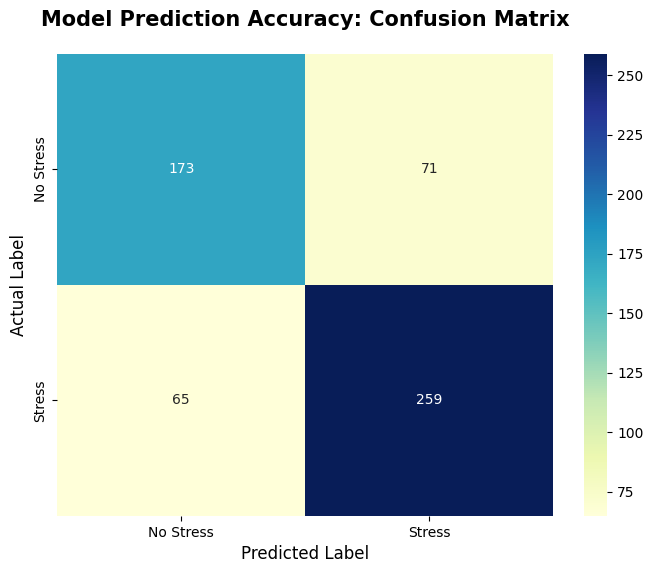

In [22]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# 1. Create the confusion matrix
cm = confusion_matrix(y_test, y_pred)

# 2. Plot it using Seaborn for a "heatmap" look
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlGnBu', 
            xticklabels=['No Stress', 'Stress'], 
            yticklabels=['No Stress', 'Stress'])

plt.title('Model Prediction Accuracy: Confusion Matrix', fontsize=15, fontweight='bold', pad=20)#predictions vs reality
plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('Actual Label', fontsize=12)

plt.show()
